# Bleeding vs ischaemic CATE — the treatment trade-off plane

The per-endpoint causal forests give each patient a CATE for **every** outcome, so we can look
at more than one endpoint at a time. This notebook puts a patient's **bleeding** CATE on one axis
and an **ischaemic** CATE on the other and asks the clinical question the single-endpoint views
cannot: *are there patients who would gain a lot from abbreviating on bleeding but pay a large
ischaemic penalty for it?* Those are the patients for whom the abbreviate-vs-prolong decision is a
genuine trade-off rather than a free lunch, and if they cluster together they define a subgroup
worth flagging.

**Treatment coding (identical to nb 06/07):** `T = 1` prolonged DAPT, `T = 0` abbreviated DAPT, so

$$\text{CATE}_k(x) = \operatorname{risk}_k(\text{prolonged}) - \operatorname{risk}_k(\text{abbreviated}).$$

Read as the **benefit of abbreviating**: `CATE_k > 0` → abbreviating *lowers* endpoint `k`
(a benefit of shortening); `CATE_k < 0` → abbreviating *raises* it (a harm of shortening).
Both axes use this same signed convention, so the four quadrants have a fixed meaning:

| quadrant | bleeding CATE | ischaemic CATE | reading |
|---|---|---|---|
| top-right | > 0 | > 0 | **win–win**: abbreviate (fewer bleeds *and* fewer ischaemic events) |
| **bottom-right** | **> 0** | **< 0** | **trade-off / conflict**: abbreviating stops bleeds but costs ischaemic events |
| bottom-left | < 0 | < 0 | **lose–lose**: keep prolonged |
| top-left | < 0 | > 0 | prolonging bleeds them yet abbreviating still costs ischaemia |

The **bottom-right** quadrant is the one we hunt for.

The model is loaded **only by path** (see the CONFIG cell): point the two axes at any saved
`CausalMultiOutputPipeline` — the tuned multi-output causal forest here, a preset level, the BCF,
or a per-endpoint tuned forest — and the rest of the notebook is unchanged.


In [24]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

HERE = os.getcwd()
MODELS_DIR = os.path.normpath(os.path.join(HERE, "..", "models"))
DATA_DIR   = os.path.normpath(os.path.join(HERE, "..", "..", "data"))
CF_DIR     = os.path.join(MODELS_DIR, "CausalForest")
FIG_DIR    = os.path.join(CF_DIR, "TRADEOFF")
os.makedirs(FIG_DIR, exist_ok=True)
print("models dir:", MODELS_DIR)

import warnings
warnings.filterwarnings("ignore")

models dir: /home/tpioda/Bachelor-Thesis/Meta-learning/models


## 1 · Configuration — *change the model here*

Everything downstream reads the two axes from `AXES`. Each entry is a `(path, endpoint)` pair:

* `path` — any saved `CausalMultiOutputPipeline` (`.joblib`). It may be the bare pipeline
  (nb 06's multi-output fit) or a `dict` wrapping it under `"pipe"` (the per-endpoint tuned
  forests from `analyze_ischemic_tuning.py`).
* `endpoint` — the outcome to read, either a label from
  `["barc_235", "death", "mi", "stroke", "bleed"]` or an integer column index. For a
  single-endpoint (`dict`) model the label is auto-detected, so `0` always works.

To score a **different model**, edit only the paths below — e.g. swap
`CausalForest_multioutput_tuned.joblib` for `.../BCF/BCF_multioutput.joblib` or
`CausalForest_multioutput_flexible.joblib`.

In [25]:
# ============================ CONFIG ============================
# The bleeding axis (x) and the ischaemic axes (y candidates). Swap paths to change model.
MULTIOUT = os.path.join(CF_DIR, "CausalForest_multioutput_tuned.joblib")

BLEED_AXIS = {"path": MULTIOUT, "endpoint": "bleed"}          # x-axis: bleeding benefit of abbreviating

ISCHAEMIC_AXES = {                                            # y-axis candidates
    "death":  {"path": MULTIOUT, "endpoint": "death"},
    "mi":     {"path": MULTIOUT, "endpoint": "mi"},
    "stroke": {"path": MULTIOUT, "endpoint": "stroke"},
}
ISCHAEMIC_WEIGHTS = {"death": 0.2, "mi": 0.4, "stroke": 0.4}  # weights for the combined ischaemic score
PRIMARY_ISCHAEMIC = "mi"      # single endpoint drawn on the main 2-D plane (see the sign check below)

CONFLICT_PCT = 15.0           # top-% by conflict score flagged as the trade-off subgroup
RANDOM_STATE = 42
# ===============================================================
print("bleeding axis :", BLEED_AXIS)
print("ischaemic axes:", list(ISCHAEMIC_AXES))
print("primary ischaemic endpoint (main plane y):", PRIMARY_ISCHAEMIC)

bleeding axis : {'path': '/home/tpioda/Bachelor-Thesis/Meta-learning/models/CausalForest/CausalForest_multioutput_tuned.joblib', 'endpoint': 'bleed'}
ischaemic axes: ['death', 'mi', 'stroke']
primary ischaemic endpoint (main plane y): mi


## 2 · Model-agnostic CATE loader

`cate_for(axis)` is the single point of contact with the model: it opens the joblib, applies
**that model's own** imputer + scaler to the shared raw `X`, and returns the per-patient CATE for
the requested endpoint. Because each saved pipeline carries its own preprocessing, mixing models
across axes stays correct — only the CONFIG paths decide what is loaded.

In [26]:
TARGET_LABELS = ["barc_235", "death", "mi", "stroke", "bleed"]  # column order of Y / the fitted models

_PIPE_CACHE = {}

def load_cf_pipeline(path):
    '''Return (pipeline, label->index). Handles a bare CausalMultiOutputPipeline or a
    dict {"pipe":..., "outcome":...} from the per-endpoint tuners.'''
    if path in _PIPE_CACHE:
        return _PIPE_CACHE[path]
    obj = joblib.load(path)
    if isinstance(obj, dict):
        pipe = obj["pipe"]
        # single-endpoint model: its one forest sits at index 0
        label = obj.get("outcome")
        idx_map = {label: 0} if label else {}
        idx_map.setdefault(0, 0)
    else:
        pipe = obj
        n = len(pipe.models)
        idx_map = {lab: i for i, lab in enumerate(TARGET_LABELS[:n])}
    _PIPE_CACHE[path] = (pipe, idx_map)
    return pipe, idx_map

def _resolve_idx(endpoint, idx_map, n_models):
    if isinstance(endpoint, (int, np.integer)):
        return int(endpoint)
    if endpoint in idx_map:
        return idx_map[endpoint]
    if endpoint in TARGET_LABELS and TARGET_LABELS.index(endpoint) < n_models:
        return TARGET_LABELS.index(endpoint)
    raise KeyError(f"endpoint {endpoint!r} not available (have {idx_map})")

def cate_for(axis, X_raw):
    '''Per-patient CATE for one CONFIG axis, using the model's own preprocessing.'''
    pipe, idx_map = load_cf_pipeline(axis["path"])
    idx = _resolve_idx(axis["endpoint"], idx_map, len(pipe.models))
    X_df = pd.DataFrame(X_raw).apply(pd.to_numeric, errors="coerce")
    X_scaled = pipe.scaler.transform(pipe.imputer_x.transform(X_df))
    model = pipe.models[idx]
    if model is None:
        raise ValueError(f"model index {idx} is None in {os.path.basename(axis['path'])}")
    return np.asarray(model.effect(X_scaled)).ravel()

print("loaders ready")

loaders ready


## 3 · Data

`tuning_data.npz` holds the exact `X / Y / T` the forests were fit on (numeric features in fitted
order), so every model's CATE is aligned to the same patients. Feature names come from
`X_features.parquet` for the subgroup profiling later.

In [27]:
d = np.load(os.path.join(HERE, "tuning_data.npz"), allow_pickle=True)
X_raw = d["X"]                       # (n, 180) object -> numeric
T = d["T"].astype(int)
Y = pd.DataFrame(d["Y"], columns=TARGET_LABELS).apply(pd.to_numeric, errors="coerce")
n = X_raw.shape[0]

# feature names in the model's column order (numeric columns of X_features.parquet)
try:
    Xfeat = pd.read_parquet(os.path.join(DATA_DIR, "X_features.parquet"))
    feat_names = list(Xfeat.select_dtypes(include=[np.number]).columns)
    if len(feat_names) != X_raw.shape[1]:
        feat_names = [f"x{i}" for i in range(X_raw.shape[1])]
except Exception:
    feat_names = [f"x{i}" for i in range(X_raw.shape[1])]

print(f"n = {n} patients | {X_raw.shape[1]} features | "
      f"{int((T==1).sum())} prolonged, {int((T==0).sum())} abbreviated")

n = 4579 patients | 63 features | 2284 prolonged, 2295 abbreviated


## 4 · Sign & calibration sanity check *(read this before trusting an axis)*

A causal forest's **average** CATE should sit near the trial's raw ATE
$\big(\bar Y_{T=1}-\bar Y_{T=0}\big)$ and, above all, **agree in sign**. Where it does not, the
endpoint's heterogeneity signal is unreliable and a poor choice of axis. We therefore print, per
endpoint, the raw ATE next to the model's mean CATE and flag sign agreement.

In [28]:
rows = []
for lab in TARGET_LABELS:
    ate = Y.loc[T == 1, lab].mean() - Y.loc[T == 0, lab].mean()
    c = cate_for({"path": MULTIOUT, "endpoint": lab}, X_raw)
    rows.append({"endpoint": lab, "raw_ATE": ate, "model_meanCATE": c.mean(),
                 "model_stdCATE": c.std(),
                 "sign_ok": "yes" if np.sign(ate) == np.sign(c.mean()) else "NO",
                 "spread": "flat" if c.std() < 1e-3 else "ok"})
sign_tbl = pd.DataFrame(rows).set_index("endpoint")
print(sign_tbl.round(4).to_string())
print("\n-> use endpoints with sign_ok=yes AND spread=ok as axes; the others are shown but "
      "flagged. `bleed` is the configured default bleeding axis; if an endpoint's forest CATE "
      "sign-flips vs its ATE (as barc_235 did with some earlier tuned models), prefer a "
      "sign_ok=yes axis instead.")

          raw_ATE  model_meanCATE  model_stdCATE sign_ok spread
endpoint                                                       
barc_235   0.0279          0.0263         0.0048     yes     ok
death      0.0031          0.0021         0.0019     yes     ok
mi        -0.0047         -0.0039         0.0033     yes     ok
stroke     0.0048          0.0036         0.0060     yes     ok
bleed      0.0451          0.0439         0.0062     yes     ok

-> use endpoints with sign_ok=yes AND spread=ok as axes; the others are shown but flagged. `bleed` is the configured default bleeding axis; if an endpoint's forest CATE sign-flips vs its ATE (as barc_235 did with some earlier tuned models), prefer a sign_ok=yes axis instead.


## 5 · Per-patient CATEs and the conflict score

Assemble one row per patient: the bleeding-axis CATE, each ischaemic CATE, a weighted **combined
ischaemic** benefit, and a **conflict score**

$$\text{conflict} = z(\text{bleed benefit}) - z(\text{ischaemic benefit}),$$

standardised so the two miscalibrated scales are comparable. It is large-positive exactly for the
bottom-right patients (abbreviating helps bleeding but hurts ischaemia).

In [29]:
df = pd.DataFrame(index=np.arange(n))
df["bleed"] = cate_for(BLEED_AXIS, X_raw)
for name, ax in ISCHAEMIC_AXES.items():
    df[name] = cate_for(ax, X_raw)

def _z(s):
    return (s - s.mean()) / (s.std() if s.std() > 0 else 1.0)

w = ISCHAEMIC_WEIGHTS
df["ischaemic_combined"] = sum(w[k] * _z(df[k]) for k in ISCHAEMIC_AXES) / sum(w.values())

# conflict = abbreviating is good for bleeding (high) but bad for ischaemia (low)
df["conflict"] = _z(df["bleed"]) - _z(df["ischaemic_combined"])

print(df[["bleed", *ISCHAEMIC_AXES, "ischaemic_combined", "conflict"]].describe().round(4).to_string())

           bleed      death         mi     stroke  ischaemic_combined   conflict
count  4579.0000  4579.0000  4579.0000  4579.0000           4579.0000  4579.0000
mean      0.0439     0.0021    -0.0039     0.0036             -0.0000    -0.0000
std       0.0062     0.0019     0.0033     0.0060              0.4507     1.4563
min       0.0253    -0.0036    -0.0143    -0.0047             -1.3681    -5.2205
25%       0.0397     0.0008    -0.0061    -0.0008             -0.3135    -0.9799
50%       0.0441     0.0017    -0.0037     0.0008             -0.0358     0.0547
75%       0.0485     0.0032    -0.0014     0.0080              0.2828     1.0544
max       0.0621     0.0108     0.0055     0.0191              1.6147     4.5586


## 6 · The trade-off plane

`x = bleeding benefit of abbreviating`, `y = ischaemic benefit of abbreviating` (primary endpoint).
Zero lines split the four quadrants above; the density (hexbin) shows where the mass actually sits,
and the points are tinted by the conflict score so the **bottom-right** trade-off patients stand
out. The shaded box marks the flagged conflict subgroup's region.

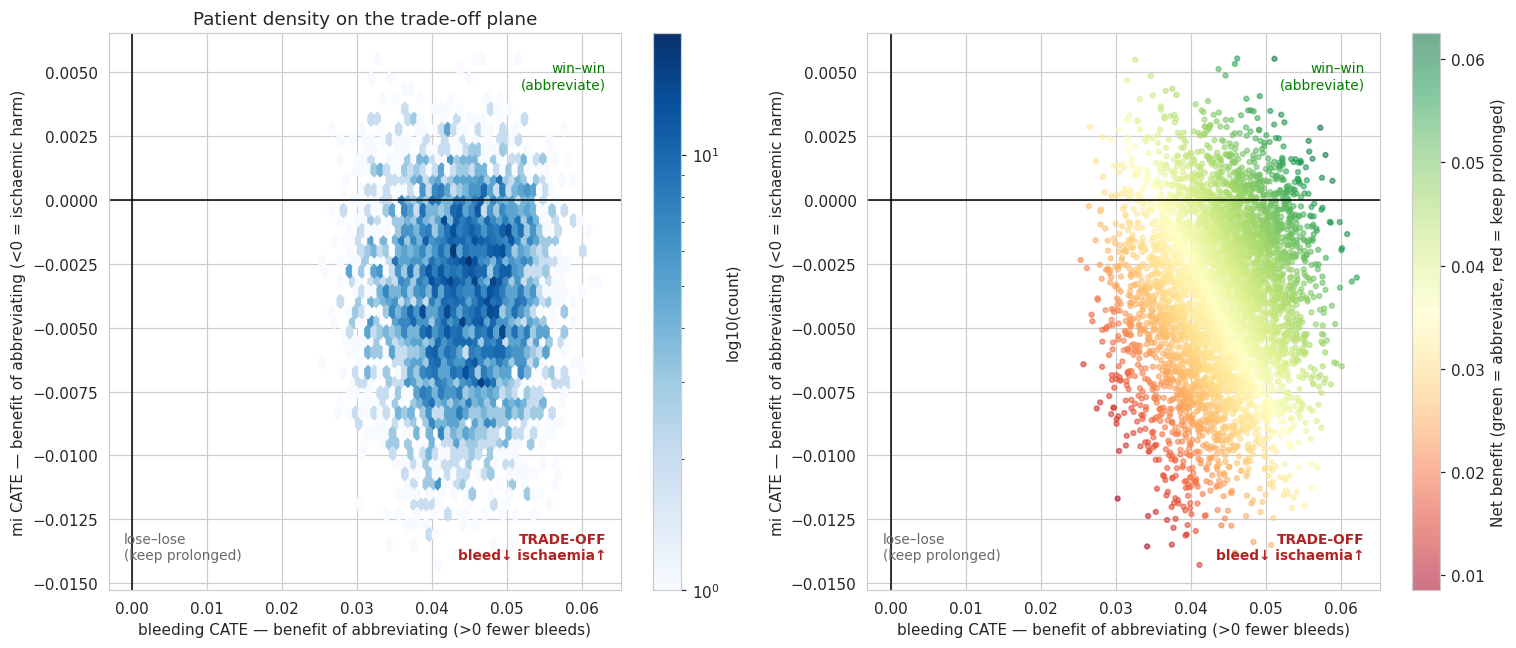

In [30]:
from scipy.stats import linregress

yname = PRIMARY_ISCHAEMIC
vision_weight = 1 / ((max(df[yname]) - min(df[yname])) / (max(df["bleed"]) - min(df["bleed"])))

x, y = df["bleed"].to_numpy(), df[yname].to_numpy()
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6))

# slope strength
"""
mask = np.isfinite(x) & np.isfinite(y)
slope, intercept, r_value, p_value, stderr = linregress(x[mask], y[mask])
r2 = r_value ** 2
x_line = np.linspace(np.min(x), np.max(x), 100)
y_line = intercept + slope * x_line
"""

# net benefit: high when bleed benefit AND ischaemic benefit are both high (same sign convention -> sum)
net_benefit = df["bleed"] + df[yname] * vision_weight

# left: density
hb = axL.hexbin(x, y, gridsize=45, cmap="Blues", mincnt=1, bins="log")
fig.colorbar(hb, ax=axL, label="log10(count)")
axL.set_title("Patient density on the trade-off plane")

# right: points tinted by net benefit
sc = axR.scatter(x, y, c=net_benefit, cmap="RdYlGn", s=10, alpha=0.55)
fig.colorbar(sc, ax=axR, label="Net benefit (green = abbreviate, red = keep prolonged)")

"""
# regression slope
axR.plot(x_line, y_line, color="black", lw=3, linestyle="--",
         label=f"slope={slope:.2f}\nR²={r2:.2f}\nr={r_value:.2f}")
axR.legend(loc="upper left")
axR.set_title("Coloured by net benefit of abbreviating")
"""

for ax in (axL, axR):
    ax.axvline(0, color="k", lw=1)
    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("bleeding CATE — benefit of abbreviating (>0 fewer bleeds)")
    ax.set_ylabel(f"{yname} CATE — benefit of abbreviating (<0 = ischaemic harm)")
    ax.annotate("win–win\n(abbreviate)", (0.97, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=9, color="green")
    ax.annotate("TRADE-OFF\nbleed↓ ischaemia↑", (0.97, 0.05), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=9, color="firebrick", weight="bold")
    ax.annotate("lose–lose\n(keep prolonged)", (0.03, 0.05), xycoords="axes fraction",
                ha="left", va="bottom", fontsize=9, color="dimgray")

#fig.suptitle(f"Bleeding vs {yname}: benefit of abbreviating per patient\n"
#             f"Slope strength: β={slope:.2f}, R²={r2:.2f}", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"tradeoff_bleed_vs_{yname}.png"), dpi=150, bbox_inches="tight")
plt.show()

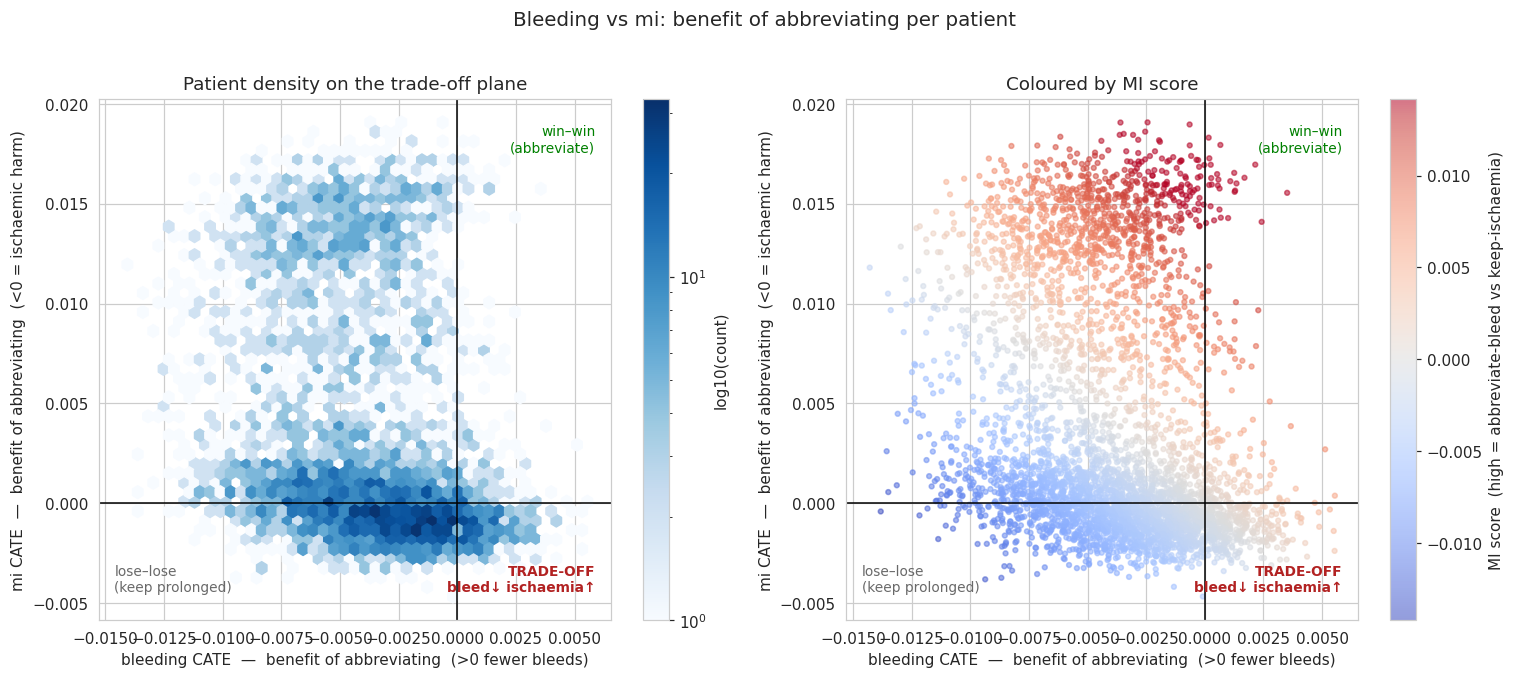

In [31]:
x, y = df["mi"].to_numpy(), df['stroke'].to_numpy()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6))

# -- left: density
hb = axL.hexbin(x, y, gridsize=45, cmap="Blues", mincnt=1, bins="log")
fig.colorbar(hb, ax=axL, label="log10(count)")
axL.set_title("Patient density on the trade-off plane")

# -- right: points tinted by conflict
sc = axR.scatter(x, y, c=df['stroke'] + df["mi"], cmap="coolwarm", s=10, alpha=0.55,
                 vmin=-np.abs(df['stroke'] + df["mi"]).quantile(0.98),
                 vmax=np.abs(df['stroke'] + df["mi"]).quantile(0.98))
fig.colorbar(sc, ax=axR, label="MI score  (high = abbreviate-bleed vs keep-ischaemia)")
axR.set_title("Coloured by MI score")

for ax in (axL, axR):
    ax.axvline(0, color="k", lw=1); ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("bleeding CATE  —  benefit of abbreviating  (>0 fewer bleeds)")
    ax.set_ylabel(f"{yname} CATE  —  benefit of abbreviating  (<0 = ischaemic harm)")
    ax.annotate("win–win\n(abbreviate)", (0.97, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=9, color="green")
    ax.annotate("TRADE-OFF\nbleed↓ ischaemia↑", (0.97, 0.05), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=9, color="firebrick", weight="bold")
    ax.annotate("lose–lose\n(keep prolonged)", (0.03, 0.05), xycoords="axes fraction",
                ha="left", va="bottom", fontsize=9, color="dimgray")

fig.suptitle(f"Bleeding vs {yname}: benefit of abbreviating per patient", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"tradeoff_bleed_vs_{yname}.png"), dpi=150, bbox_inches="tight")
plt.show()

### Bleeding against each ischaemic endpoint

The tension is endpoint-specific — MI carries the classic ischaemic benefit of *longer* DAPT,
while death/stroke are weaker. Small multiples make each pairing visible; the Pearson `r` in each
title is the bleeding–ischaemia CATE correlation (negative `r` ⇒ the two goals genuinely pull
apart across patients).

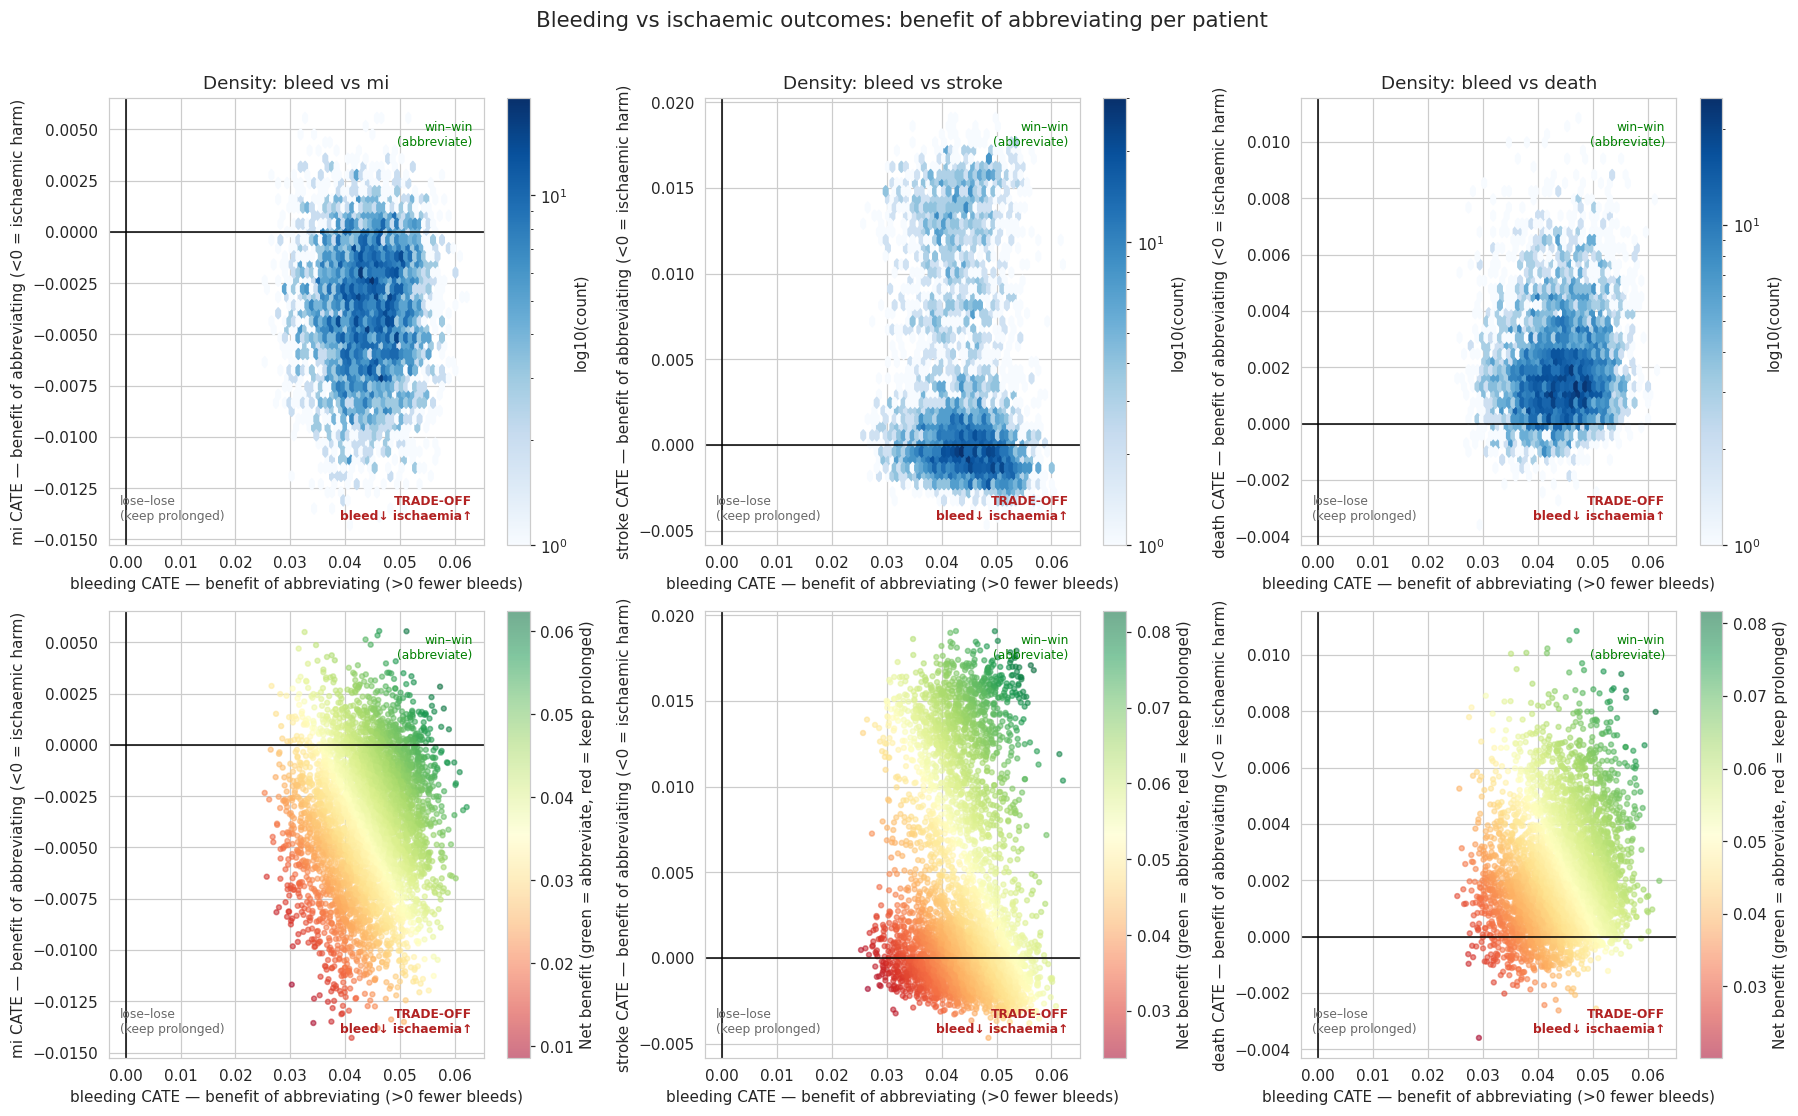

In [32]:
from scipy.stats import linregress

outcomes = ["mi", "stroke", "death"]
fig, axes = plt.subplots(2, len(outcomes), figsize=(5.5 * len(outcomes), 10))

for col, yname in enumerate(outcomes):
    axL, axR = axes[0, col], axes[1, col]
    x, y = df["bleed"].to_numpy(), df[yname].to_numpy()

    # slope strength
    mask = np.isfinite(x) & np.isfinite(y)
    slope, intercept, r_value, p_value, stderr = linregress(x[mask], y[mask])
    r2 = r_value ** 2
    x_line = np.linspace(np.min(x), np.max(x), 100)
    y_line = intercept + slope * x_line

    # net benefit: high when bleed benefit AND ischaemic benefit are both high (same sign -> sum)
    vision_weight = 1 / ((max(df[yname]) - min(df[yname])) / (max(df["bleed"]) - min(df["bleed"])))
    net_benefit = df["bleed"] + df[yname] * vision_weight

    # top row: density
    hb = axL.hexbin(x, y, gridsize=45, cmap="Blues", mincnt=1, bins="log")
    fig.colorbar(hb, ax=axL, label="log10(count)")
    axL.set_title(f"Density: bleed vs {yname}")

    
    # bottom row: points tinted by net benefit + slope
    sc = axR.scatter(x, y, c=net_benefit, cmap="RdYlGn", s=10, alpha=0.55)
    fig.colorbar(sc, ax=axR, label="Net benefit (green = abbreviate, red = keep prolonged)")
    """
    axR.plot(x_line, y_line, color="black", lw=3, linestyle="--",
             label=f"slope={slope:.2f}\nR²={r2:.2f}\nr={r_value:.2f}")
    axR.legend(loc="upper left")
    axR.set_title(f"Slope: bleed vs {yname}")
    """

    for ax in (axL, axR):
        ax.axvline(0, color="k", lw=1)
        ax.axhline(0, color="k", lw=1)
        ax.set_xlabel("bleeding CATE — benefit of abbreviating (>0 fewer bleeds)")
        ax.set_ylabel(f"{yname} CATE — benefit of abbreviating (<0 = ischaemic harm)")
        ax.annotate("win–win\n(abbreviate)", (0.97, 0.95), xycoords="axes fraction",
                    ha="right", va="top", fontsize=8, color="green")
        ax.annotate("TRADE-OFF\nbleed↓ ischaemia↑", (0.97, 0.05), xycoords="axes fraction",
                    ha="right", va="bottom", fontsize=8, color="firebrick", weight="bold")
        ax.annotate("lose–lose\n(keep prolonged)", (0.03, 0.05), xycoords="axes fraction",
                    ha="left", va="bottom", fontsize=8, color="dimgray")

fig.suptitle("Bleeding vs ischaemic outcomes: benefit of abbreviating per patient", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tradeoff_bleed_grid.png"), dpi=150, bbox_inches="tight")
plt.show()

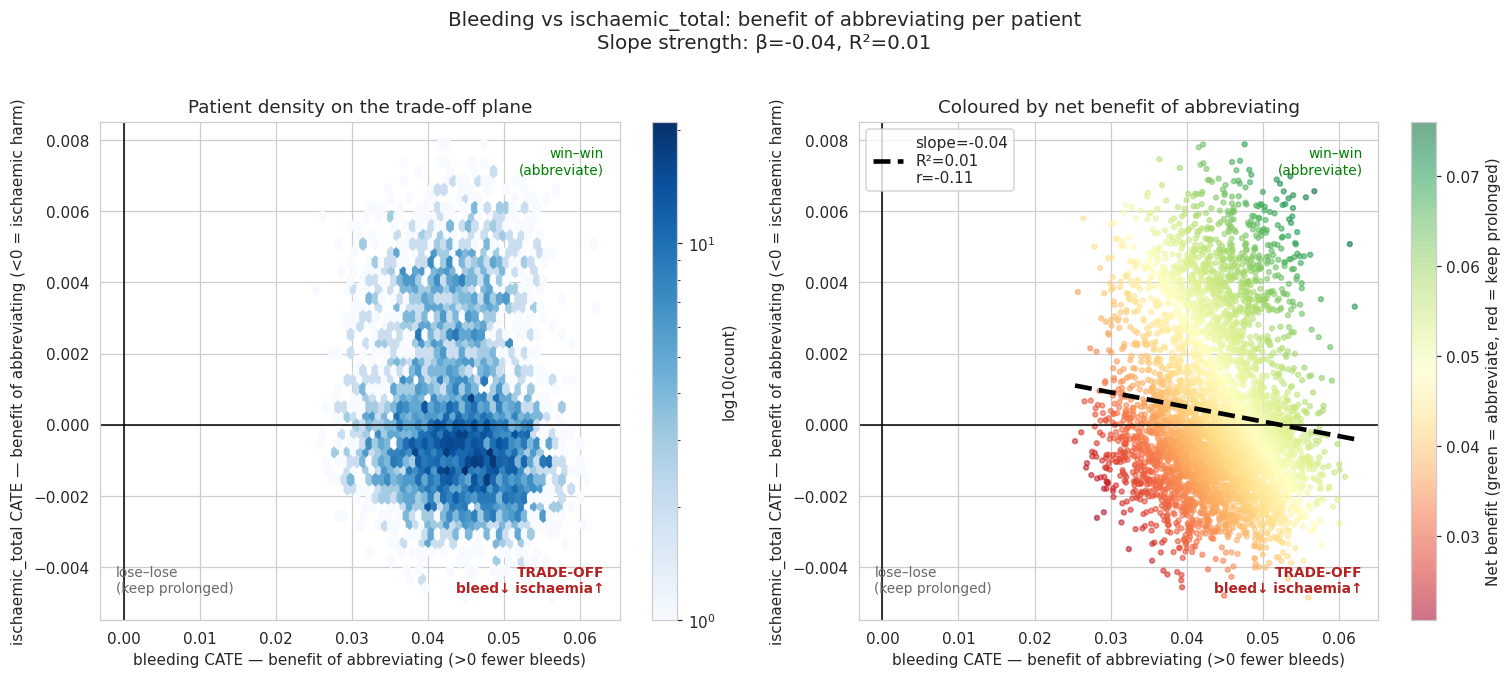

In [33]:
from scipy.stats import linregress

yname = "ischaemic_total"
x = df["bleed"].to_numpy()
y = (df["death"] * 0.2 + df["stroke"] * 0.4 + df["mi"] * 0.4).to_numpy()

# slope strength
mask = np.isfinite(x) & np.isfinite(y)
slope, intercept, r_value, p_value, stderr = linregress(x[mask], y[mask])
r2 = r_value ** 2
x_line = np.linspace(np.min(x), np.max(x), 100)
y_line = intercept + slope * x_line

# net benefit: high when bleed benefit AND ischaemic benefit are both high (same sign -> sum)
vision_weight = 1 / ((max(y) - min(y)) / (max(x) - min(x)))
net_benefit = x + y * vision_weight

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6))

# left: density
hb = axL.hexbin(x, y, gridsize=45, cmap="Blues", mincnt=1, bins="log")
fig.colorbar(hb, ax=axL, label="log10(count)")
axL.set_title("Patient density on the trade-off plane")

# right: points tinted by net benefit + slope
sc = axR.scatter(x, y, c=net_benefit, cmap="RdYlGn", s=10, alpha=0.55)
fig.colorbar(sc, ax=axR, label="Net benefit (green = abbreviate, red = keep prolonged)")
axR.plot(x_line, y_line, color="black", lw=3, linestyle="--",
         label=f"slope={slope:.2f}\nR²={r2:.2f}\nr={r_value:.2f}")
axR.legend(loc="upper left")
axR.set_title("Coloured by net benefit of abbreviating")

for ax in (axL, axR):
    ax.axvline(0, color="k", lw=1)
    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("bleeding CATE — benefit of abbreviating (>0 fewer bleeds)")
    ax.set_ylabel(f"{yname} CATE — benefit of abbreviating (<0 = ischaemic harm)")
    ax.annotate("win–win\n(abbreviate)", (0.97, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=9, color="green")
    ax.annotate("TRADE-OFF\nbleed↓ ischaemia↑", (0.97, 0.05), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=9, color="firebrick", weight="bold")
    ax.annotate("lose–lose\n(keep prolonged)", (0.03, 0.05), xycoords="axes fraction",
                ha="left", va="bottom", fontsize=9, color="dimgray")

fig.suptitle(f"Bleeding vs {yname}: benefit of abbreviating per patient\n"
             f"Slope strength: β={slope:.2f}, R²={r2:.2f}", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"tradeoff_bleed_vs_{yname}.png"), dpi=150, bbox_inches="tight")
plt.show()

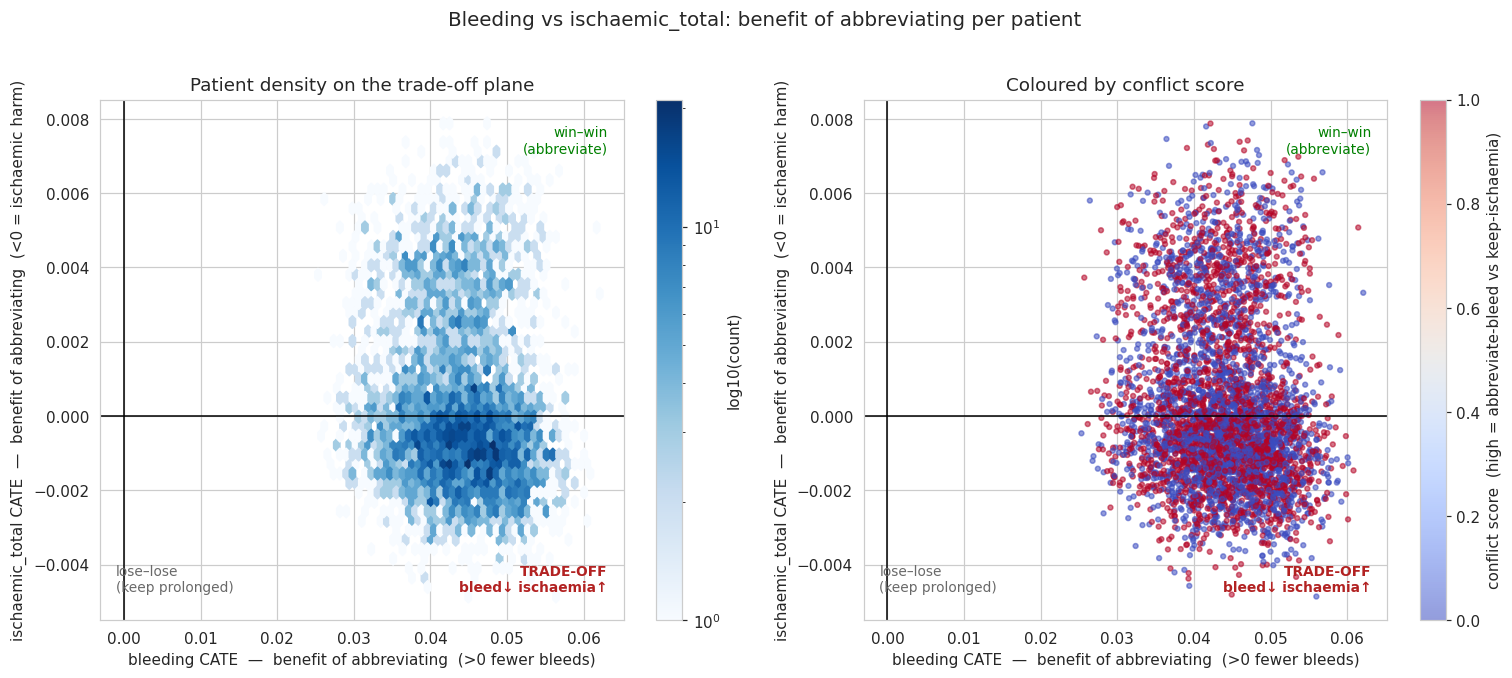

In [34]:
x, y = df["bleed"].to_numpy(), (df['death']*0.2 + df['stroke']*0.4 + df['mi']*0.4).to_numpy()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6))

# -- left: density
hb = axL.hexbin(x, y, gridsize=45, cmap="Blues", mincnt=1, bins="log")
fig.colorbar(hb, ax=axL, label="log10(count)")
axL.set_title("Patient density on the trade-off plane")

# -- right: points tinted by conflict
sc = axR.scatter(x, y, c=T, cmap="coolwarm", s=10, alpha=0.55)
fig.colorbar(sc, ax=axR, label="conflict score  (high = abbreviate-bleed vs keep-ischaemia)")
axR.set_title("Coloured by conflict score")

for ax in (axL, axR):
    ax.axvline(0, color="k", lw=1); ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("bleeding CATE  —  benefit of abbreviating  (>0 fewer bleeds)")
    ax.set_ylabel(f"{yname} CATE  —  benefit of abbreviating  (<0 = ischaemic harm)")
    ax.annotate("win–win\n(abbreviate)", (0.97, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=9, color="green")
    ax.annotate("TRADE-OFF\nbleed↓ ischaemia↑", (0.97, 0.05), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=9, color="firebrick", weight="bold")
    ax.annotate("lose–lose\n(keep prolonged)", (0.03, 0.05), xycoords="axes fraction",
                ha="left", va="bottom", fontsize=9, color="dimgray")

fig.suptitle(f"Bleeding vs {yname}: benefit of abbreviating per patient", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"tradeoff_bleed_vs_{yname}.png"), dpi=150, bbox_inches="tight")
plt.show()

=== training rule (|conflict|) ===
                n           MI       stroke MI or stroke
abbreviated  2289  2.7% ± 0.7%  1.1% ± 0.4%  3.8% ± 0.8%
prolonged    2289  2.1% ± 0.6%  0.4% ± 0.3%  2.4% ± 0.6%
all (test)   4578  2.4% ± 0.4%  0.8% ± 0.3%  3.1% ± 0.5%
RR=1.55  OR=1.58  Fisher p=0.011
n abbreviated=2289, prolonged=2289

=== training + ischemic gate ===
                n           MI       stroke MI or stroke
abbreviated  1571  2.4% ± 0.7%  1.3% ± 0.6%  3.6% ± 0.9%
prolonged    3007  2.4% ± 0.5%  0.5% ± 0.3%  2.9% ± 0.6%
all (test)   4578  2.4% ± 0.4%  0.8% ± 0.3%  3.1% ± 0.5%
RR=1.23  OR=1.24  Fisher p=0.245
n abbreviated=1571, prolonged=3007

=== original policy (duel_by_angle) ===
                n           MI       stroke MI or stroke
abbreviated  2289  2.5% ± 0.6%  0.9% ± 0.4%  3.4% ± 0.7%
prolonged    2289  2.2% ± 0.6%  0.7% ± 0.3%  2.9% ± 0.7%
all (test)   4578  2.4% ± 0.4%  0.8% ± 0.3%  3.1% ± 0.5%
RR=1.17  OR=1.17  Fisher p=0.396
n abbreviated=2289, prolonged=2289

=

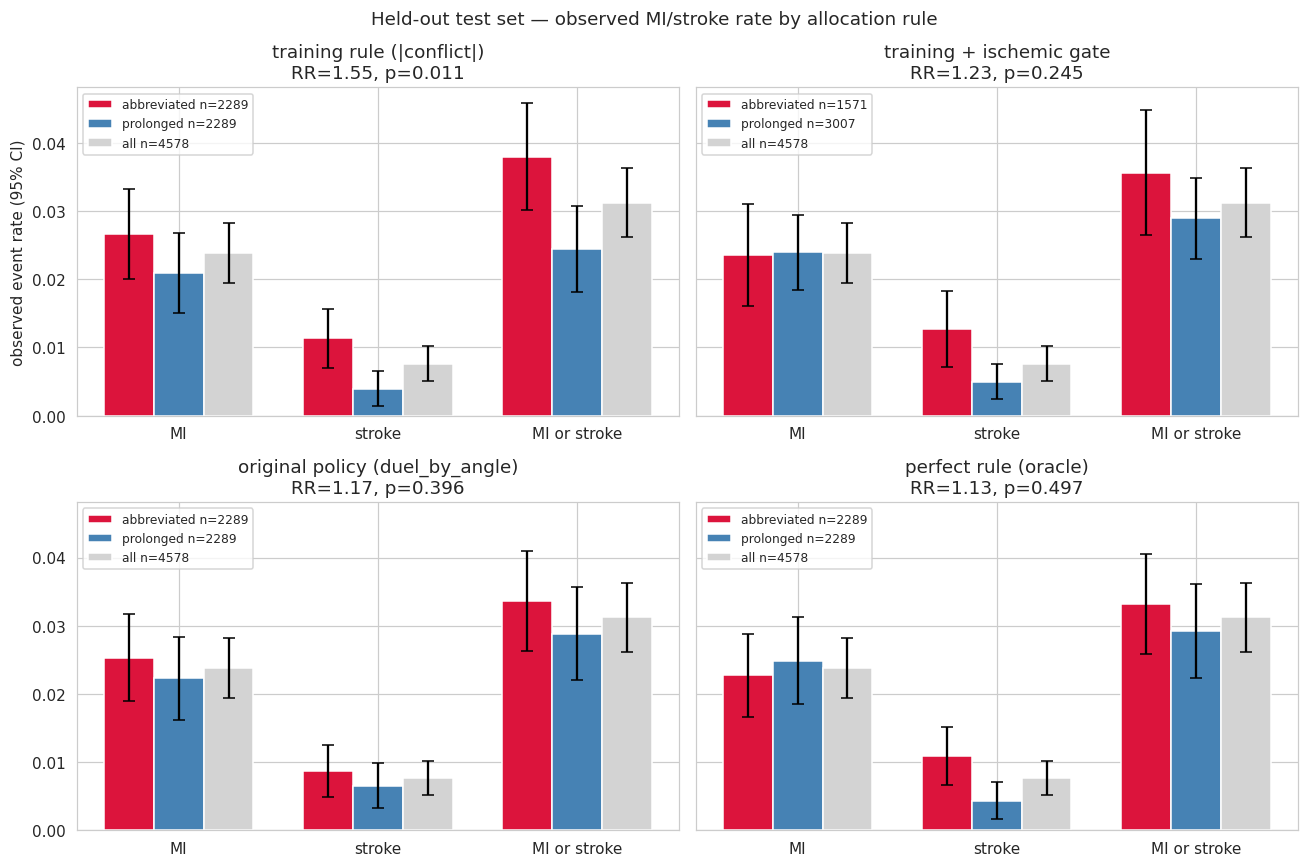

In [35]:
from scipy.stats import fisher_exact

# ── adapt the online-learning duel machinery to this notebook ─────────────────
# This notebook has no held-out split: score every patient in-sample, so the
# test-local index equals the global patient index.
test = np.arange(n)
y    = Y                                   # observed events (columns: barc_235, death, mi, stroke, bleed)

# per-patient trade-off coordinates — SAME convention/weights as the plane above
# (>0 = benefit of abbreviating; ischaemic <0 = ischaemic harm of abbreviating)
bx = df["bleed"].to_numpy()                                             # x: bleeding benefit of shortening
iy = (df["death"] * 0.2 + df["mi"] * 0.4 + df["stroke"] * 0.4).to_numpy()  # y: weighted ischaemic benefit
conf = df["conflict"].to_numpy()

def _conf(i):
    return abs(float(conf[i]))

def components_from_origin(i):
    return bx[i], iy[i]

def duel_by_angle(i, j):
    x1, y1 = components_from_origin(i)
    x2, y2 = components_from_origin(j)

    a1 = np.degrees(np.arctan2(y1, x1))
    a2 = np.degrees(np.arctan2(y2, x2))

    # angular distance to the +45° win-win diagonal (top-right: high bleed AND high ischaemic)
    d1 = abs((a1 - 45 + 180) % 360 - 180)
    d2 = abs((a2 - 45 + 180) % 360 - 180)

    if (x1 > 0 and y1 > 0) and (x2 > 0 and y2 > 0):
        return i if (x1**2 + y1**2) > (x2**2 + y2**2) else j   # both win-win: keep the one further out
    if (x1 < 0 and y1 < 0) and (x2 < 0 and y2 < 0):
        return i if (x1**2 + y1**2) < (x2**2 + y2**2) else j   # both lose-lose: keep the less-bad
    return i if d1 < d2 else j                                 # else: nearest the +45° win-win diagonal

def run_selection(select):
    """Pair up shuffled patients; `select(i, j, rng)` returns the duel winners -> abbreviated,
    the losers -> prolonged. Fixed seed for reproducibility."""
    rng = np.random.default_rng(42)
    idx = np.arange(len(test)); rng.shuffle(idx)
    abbreviated, prolonged = [], []
    for k in range(0, len(idx) - 1, 2):
        i, j    = int(idx[k]), int(idx[k + 1])
        winners = select(i, j, rng)
        abbreviated.extend(winners)
        prolonged.extend([p for p in (i, j) if p not in winners])
    return np.asarray(abbreviated, dtype=int), np.asarray(prolonged, dtype=int)
# ──────────────────────────────────────────────────────────────────────────────

y_mi=y[['mi']].to_numpy()
y_stroke=y[['stroke']].to_numpy()
y_combo=((y_mi==1)|(y_stroke==1)).astype(int)

def rate_ci(idx,event):
    n=len(idx); p=event[idx].mean()
    return p,1.96*np.sqrt(p*(1-p)/n),n

def analyse(abbreviated,prolonged):
    test_abbrev=test[abbreviated]
    test_prolonged=test[prolonged]
    combo=np.concatenate([test_abbrev,test_prolonged])

    groups={
        'abbreviated':test_abbrev,
        'prolonged':test_prolonged,
        'all (test)':combo
    }

    table=pd.DataFrame({
        label:{
            ev_name:f'{p:.1%} ± {hw:.1%}'
            for ev_name,ev in [('MI',y_mi),('stroke',y_stroke),('MI or stroke',y_combo)]
            for p,hw,_ in [rate_ci(idx,ev)]
        }
        for label,idx in groups.items()
    }).T

    table.insert(0,'n',[len(idx) for idx in groups.values()])

    a_ev=int(y_combo[test_abbrev].sum())
    p_ev=int(y_combo[test_prolonged].sum())

    a_n=len(test_abbrev)
    p_n=len(test_prolonged)

    rr=(a_ev/a_n)/(p_ev/p_n) if p_ev else np.nan
    odds,pval=fisher_exact([[a_ev,a_n-a_ev],[p_ev,p_n-p_ev]])

    return dict(
        table=table,
        combo=combo,
        test_abbrev=test_abbrev,
        test_prolonged=test_prolonged,
        rr=rr,
        odds=odds,
        pval=pval
    )


def select_training(i,j,rng):
    return [i if _conf(i)>=_conf(j) else j]

def select_training_gated(i,j,rng):
    candidates=[p for p in (i,j) if iy[p]>0]
    return [max(candidates,key=_conf)] if candidates else []

def select_policy(i,j,rng):
    # policy(..., duel=duel_by_angle, p_unc=0) reduces to the duel winner (no uncertainty exploration)
    return [duel_by_angle(i,j)]

def select_perfect(i,j,rng):
    if iy[i]>0 and iy[j]>0:
        return [i if iy[i]>=iy[j] else j]
    if iy[i]>0:
        return [i]
    if iy[j]>0:
        return [j]
    return [i if iy[i]<=iy[j] else j]


options=[
    ('training rule (|conflict|)',select_training),
    ('training + ischemic gate',select_training_gated),
    ('original policy (duel_by_angle)',select_policy),
    ('perfect rule (oracle)',select_perfect)
]

results={name:analyse(*run_selection(sel)) for name,sel in options}

for name,r in results.items():
    print(f'=== {name} ===')
    print(r['table'].to_string())
    print(f"RR={r['rr']:.2f}  OR={r['odds']:.2f}  Fisher p={r['pval']:.3f}")
    print(f"n abbreviated={len(r['test_abbrev'])}, prolonged={len(r['test_prolonged'])}\n")


labels=['MI','stroke','MI or stroke']
events=[y_mi,y_stroke,y_combo]

xpos=np.arange(len(labels))
w=.25

fig,axes=plt.subplots(2,2,figsize=(12,8),sharey=True)
axes=axes.ravel()

for ax,(name,r) in zip(axes,results.items()):
    ta,tp,cb=r['test_abbrev'],r['test_prolonged'],r['combo']

    p_ab,hw_ab=zip(*[rate_ci(ta,e)[:2] for e in events])
    p_pr,hw_pr=zip(*[rate_ci(tp,e)[:2] for e in events])
    p_all,hw_all=zip(*[rate_ci(cb,e)[:2] for e in events])

    ax.bar(xpos-w,p_ab,width=w,yerr=hw_ab,color='crimson',capsize=4,label=f'abbreviated n={len(ta)}')
    ax.bar(xpos,p_pr,width=w,yerr=hw_pr,color='steelblue',capsize=4,label=f'prolonged n={len(tp)}')
    ax.bar(xpos+w,p_all,width=w,yerr=hw_all,color='lightgray',capsize=4,label=f'all n={len(cb)}')

    ax.set_xticks(xpos)
    ax.set_xticklabels(labels)
    ax.set_title(f"{name}\nRR={r['rr']:.2f}, p={r['pval']:.3f}")
    ax.legend(fontsize=8)

axes[0].set_ylabel('observed event rate (95% CI)')
fig.suptitle('Held-out test set — observed MI/stroke rate by allocation rule')
plt.tight_layout()
plt.show()

## 6b · Bootstrap the plane — *refit* the forest, don't reshuffle the predictions

Everything above is a single fit, so the plane has no error bars: we cannot tell a real trade-off
corner from a patient that merely landed there by chance. The fix is a **nonparametric bootstrap**.

The one thing that does *not* work is resampling `X` at predict time. A fitted forest's
`effect(x)` is a deterministic, row-wise function: feed it a permuted `X` and it returns the very
same CATEs in permuted order. Averaging those permutations does not estimate uncertainty — it
silently pairs each patient with a *random other patient's* CATE, so every row converges to the
cohort mean. Uncertainty about a CATE lives in the **training sample**, so each replicate must:

1. resample the patients **with replacement** (`replace=True` — a permutation is not a bootstrap),
2. **refit** the tuned forest spec on that resample (same `cf_params` as the loaded model), and
3. predict on the **original, unshuffled** `X_raw`, keeping every row aligned to its patient.

The spread across replicates is then the honest uncertainty of each patient's position on the
plane. Only endpoints actually used as axes are refit (`targets=`), and the result is cached to
`tradeoff_bootstrap.npz` — delete that file to recompute.

In [36]:
from joblib import Parallel, delayed

from casual_multioutput_pipeline import CausalMultiOutputPipeline

N_BOOT = 50
BOOT_CACHE = os.path.join(CF_DIR, "tradeoff_bootstrap.npz")
# the forest saturates at ~24 threads on this n, so spend the rest of the box on replicates
BOOT_WORKERS, FOREST_JOBS = 8, 24

# a refit reproduces one saved model, so every axis must be reading that same pipeline
_axis_paths = {BLEED_AXIS["path"], *(ax["path"] for ax in ISCHAEMIC_AXES.values())}
assert _axis_paths == {MULTIOUT}, f"bootstrap needs every axis on MULTIOUT, got {_axis_paths}"

_tuned_pipe, _tuned_map = load_cf_pipeline(MULTIOUT)
_CF_PARAMS = dict(_tuned_pipe.cf_params)                     # reuse the tuned spec -- no re-tuning
_NUISANCE = getattr(_tuned_pipe, "nuisance_params", None)

_BLEED_IDX = _resolve_idx(BLEED_AXIS["endpoint"], _tuned_map, len(_tuned_pipe.models))
_ISCH_IDX = {name: _resolve_idx(ax["endpoint"], _tuned_map, len(_tuned_pipe.models))
             for name, ax in ISCHAEMIC_AXES.items()}
_FIT_COLS = sorted({_BLEED_IDX, *_ISCH_IDX.values()})        # skip endpoints no axis reads
_Y_ARR = Y.to_numpy()


def _one_replicate(b):
    """Refit the tuned spec on bootstrap resample `b`, predict on the full original cohort."""
    idx = np.random.default_rng(b).choice(n, n, replace=True)
    pipe_b = CausalMultiOutputPipeline(cf_params=_CF_PARAMS, nuisance_params=_NUISANCE,
                                       n_jobs=FOREST_JOBS, lgbm_n_jobs=4)
    pipe_b.fit(X_raw[idx], _Y_ARR[idx], T[idx], targets=_FIT_COLS)
    # predict on X_raw itself -- never on the resample -- so row i is always patient i
    X_scaled = pipe_b.scaler.transform(pipe_b.imputer_x.transform(
        pd.DataFrame(X_raw).apply(pd.to_numeric, errors="coerce")))
    return {lab: np.asarray(pipe_b.models[i].effect(X_scaled)).ravel()
            for lab, i in [("bleed", _BLEED_IDX), *_ISCH_IDX.items()]}


if os.path.exists(BOOT_CACHE):
    _c = np.load(BOOT_CACHE)
    boot = {k: _c[k] for k in _c.files}
    print(f"loaded cached bootstrap: {BOOT_CACHE}")
else:
    reps = Parallel(n_jobs=BOOT_WORKERS, verbose=5)(
        delayed(_one_replicate)(b) for b in range(N_BOOT))
    boot = {lab: np.vstack([r[lab] for r in reps])           # (N_BOOT, n) per endpoint
            for lab in ["bleed", *ISCHAEMIC_AXES]}
    np.savez_compressed(BOOT_CACHE, **boot)
    print(f"saved bootstrap: {BOOT_CACHE}")

w = ISCHAEMIC_WEIGHTS
boot["ischaemic_combined"] = sum(w[k] * boot[k] for k in ISCHAEMIC_AXES) / sum(w.values())
boot_bleed, boot_isch = boot["bleed"], boot["ischaemic_combined"]

# always read the replicate count off the data: a cache can hold a different N_BOOT than the
# one set above, and every CI/label below must describe what was actually loaded
n_boot_used = boot_bleed.shape[0]
if n_boot_used != N_BOOT:
    print(f"NOTE: cache holds {n_boot_used} replicates, not N_BOOT={N_BOOT}. "
          f"Delete {os.path.basename(BOOT_CACHE)} to recompute.")

print(f"{n_boot_used} replicates x {boot_bleed.shape[1]} patients")
print("replicates differ (a real resample, not a permutation):",
      n_boot_used > 1 and not np.allclose(boot_bleed[0], boot_bleed[1]))

loaded cached bootstrap: /home/tpioda/Bachelor-Thesis/Meta-learning/models/CausalForest/tradeoff_bootstrap.npz
50 replicates x 4579 patients
replicates differ (a real resample, not a permutation): True


In [37]:
N_PERM = 30

# pre-compute original predictions once
X_scaled_orig = _tuned_pipe.scaler.transform(
    _tuned_pipe.imputer_x.transform(
        pd.DataFrame(X_raw).apply(pd.to_numeric, errors="coerce")))

axes      = [("bleed", _BLEED_IDX), *_ISCH_IDX.items()]
pred_orig = {lab: np.asarray(_tuned_pipe.models[i].effect(X_scaled_orig)).ravel()
             for lab, i in axes}

# perm_preds[lab] → (N_PERM, n)
perm_preds = {lab: np.empty((N_PERM, n)) for lab, _ in axes}

for p in range(N_PERM):
    perm = np.random.default_rng(p).permutation(n)

    pipe_p = CausalMultiOutputPipeline(
        cf_params=_CF_PARAMS, nuisance_params=_NUISANCE,
        n_jobs=FOREST_JOBS, lgbm_n_jobs=4)
    pipe_p.fit(X_raw[perm], _Y_ARR[perm], T[perm], targets=_FIT_COLS)

    X_scaled_p = pipe_p.scaler.transform(
        pipe_p.imputer_x.transform(
            pd.DataFrame(X_raw).apply(pd.to_numeric, errors="coerce")))

    for lab, i in axes:
        perm_preds[lab][p] = np.asarray(pipe_p.models[i].effect(X_scaled_p)).ravel()

    if (p + 1) % 1 == 0:
        print(f"  {p+1}/{N_PERM} done")

  1/30 done
  2/30 done
  3/30 done
  4/30 done
  5/30 done
  6/30 done
  7/30 done
  8/30 done
  9/30 done
  10/30 done
  11/30 done
  12/30 done
  13/30 done
  14/30 done
  15/30 done
  16/30 done
  17/30 done
  18/30 done
  19/30 done
  20/30 done
  21/30 done
  22/30 done
  23/30 done
  24/30 done
  25/30 done
  26/30 done
  27/30 done
  28/30 done
  29/30 done
  30/30 done



endpoint               mean std  median std   p95 std  mean range
-----------------------------------------------------------------
bleed                    0.0031      0.0031    0.0038      0.0131
death                    0.0015      0.0013    0.0024      0.0059
mi                       0.0017      0.0017    0.0024      0.0069
stroke                   0.0011      0.0011    0.0018      0.0048


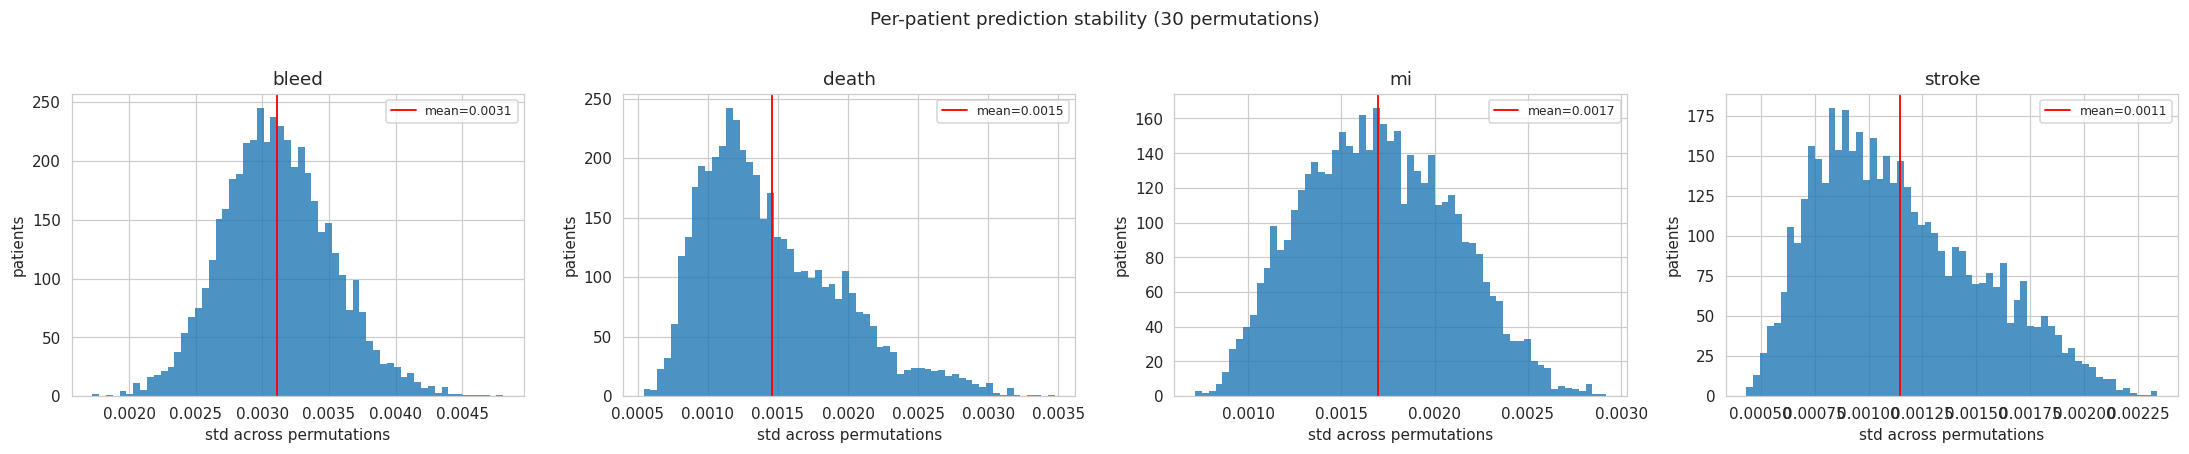

In [38]:
# ── per-row stability metrics ─────────────────────────────────────────────────
# std across permutations for each patient → shape (n,)
perm_std  = {lab: perm_preds[lab].std(axis=0)  for lab, _ in axes}
perm_range = {lab: np.ptp(perm_preds[lab], axis=0) for lab, _ in axes}   # max - min

# ── summary ───────────────────────────────────────────────────────────────────
print(f"\n{'endpoint':<20} {'mean std':>10} {'median std':>11} {'p95 std':>9} {'mean range':>11}")
print("-" * 65)
for lab, _ in axes:
    s = perm_std[lab]
    r = perm_range[lab]
    print(f"{lab:<20} {s.mean():>10.4f} {np.median(s):>11.4f} "
          f"{np.percentile(s,95):>9.4f} {r.mean():>11.4f}")

# ── plot: distribution of per-patient std ─────────────────────────────────────
fig, axes_plot = plt.subplots(1, len(axes), figsize=(5 * len(axes), 4), sharey=False)
for ax, (lab, _) in zip(axes_plot, axes):
    ax.hist(perm_std[lab], bins=60, edgecolor="none", alpha=0.8)
    ax.axvline(perm_std[lab].mean(), color="red", lw=1.2, label=f"mean={perm_std[lab].mean():.4f}")
    ax.set_xlabel("std across permutations")
    ax.set_ylabel("patients")
    ax.set_title(lab)
    ax.legend(fontsize=8)
plt.suptitle(f"Per-patient prediction stability ({N_PERM} permutations)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CF_DIR, "permutation_stability.png"), dpi=150, bbox_inches="tight")
plt.show()

### Inference: is anyone *significantly* in the trade-off corner?

Two readings of the replicates, in this order:

* **Is there heterogeneity at all?** Compare the spread of the bootstrap *mean* CATE **across
  patients** (the signal a subgroup would need) with the mean bootstrap *sd* **within** a patient
  (the noise). If the noise is the larger of the two, the plane's spread is mostly estimation
  error, and any "corner" is a chance placement.
* **Who survives?** Take each patient's percentile CI on both axes and count only those whose
  CI lies **entirely** in the bottom-right (`bleed_lo > 0` **and** `isch_hi < 0`) — a trade-off
  that the resampling could not wash out. The §8 conflict subgroup is the point-estimate answer;
  this is the one with error bars.

In [39]:
ALPHA = 5.0  # percentile CI: 5 -> 95% two-sided

boot_df = pd.DataFrame({
    "bleed_mean": boot_bleed.mean(0),
    "bleed_lo":   np.percentile(boot_bleed, ALPHA / 2, axis=0),
    "bleed_hi":   np.percentile(boot_bleed, 100 - ALPHA / 2, axis=0),
    "isch_mean":  boot_isch.mean(0),
    "isch_lo":    np.percentile(boot_isch, ALPHA / 2, axis=0),
    "isch_hi":    np.percentile(boot_isch, 100 - ALPHA / 2, axis=0),
})

# signal vs noise, per axis
print("heterogeneity signal vs bootstrap noise")
for lab, B in [("bleed", boot_bleed), ("ischaemic_combined", boot_isch)]:
    signal, noise = B.mean(0).std(), B.std(0).mean()
    print(f"  {lab:19s} across-patient sd of mean = {signal:.5f} | "
          f"within-patient bootstrap sd = {noise:.5f} | "
          f"signal/noise = {signal/noise:5.2f}  "
          f"{'-> heterogeneity exceeds noise' if signal > noise else '-> NOISE DOMINATES'}")

# who is significantly in the trade-off corner?
sig_corner = (boot_df["bleed_lo"] > 0) & (boot_df["isch_hi"] < 0)
sig_bleed = boot_df["bleed_lo"] > 0
print(f"\npatients with the whole 95% CI in the bottom-right (trade-off): "
      f"{int(sig_corner.sum())} / {n}  ({sig_corner.mean()*100:.1f}%)")
print(f"patients with a significant bleeding benefit alone (bleed_lo > 0): "
      f"{int(sig_bleed.sum())} / {n}  ({sig_bleed.mean()*100:.1f}%)")
print(f"point-estimate bottom-right, ignoring the CIs:                     "
      f"{int(((boot_df['bleed_mean'] > 0) & (boot_df['isch_mean'] < 0)).sum())} / {n}")

heterogeneity signal vs bootstrap noise
  bleed               across-patient sd of mean = 0.00811 | within-patient bootstrap sd = 0.01426 | signal/noise =  0.57  -> NOISE DOMINATES
  ischaemic_combined  across-patient sd of mean = 0.00206 | within-patient bootstrap sd = 0.00393 | signal/noise =  0.52  -> NOISE DOMINATES

patients with the whole 95% CI in the bottom-right (trade-off): 0 / 4579  (0.0%)
patients with a significant bleeding benefit alone (bleed_lo > 0): 4541 / 4579  (99.2%)
point-estimate bottom-right, ignoring the CIs:                     1544 / 4579


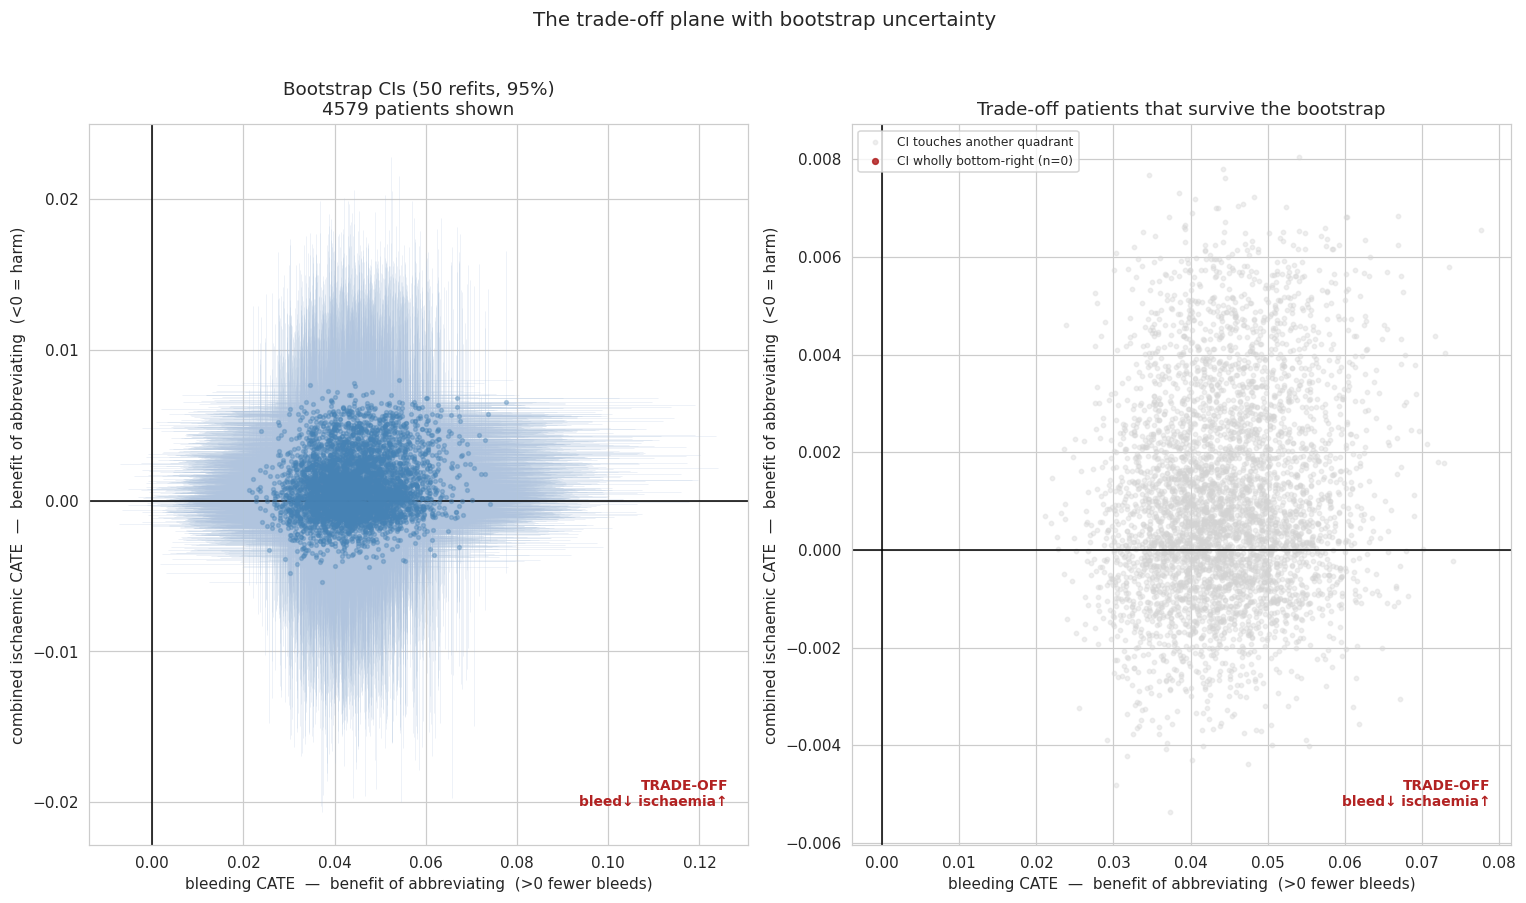

In [40]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 8))

# -- left: the plane with per-patient bootstrap CIs (thinned so the bars stay readable)
show = np.random.default_rng(RANDOM_STATE).choice(n, size=n, replace=False)
b = boot_df.iloc[show]
axL.errorbar(b["bleed_mean"], b["isch_mean"],
             xerr=[b["bleed_mean"] - b["bleed_lo"], b["bleed_hi"] - b["bleed_mean"]],
             yerr=[b["isch_mean"] - b["isch_lo"], b["isch_hi"] - b["isch_mean"]],
             fmt="o", ms=2.5, lw=0.4, alpha=0.35, color="steelblue", ecolor="lightsteelblue")
# label from the data, not N_BOOT: a loaded cache may hold a different number of replicates
axL.set_title(f"Bootstrap CIs ({n_boot_used} refits, {100-ALPHA:.0f}%)\n{len(show)} patients shown")

# -- right: every patient, red only where the whole CI sits in the trade-off corner
axR.scatter(boot_df.loc[~sig_corner, "bleed_mean"], boot_df.loc[~sig_corner, "isch_mean"],
            s=8, alpha=0.35, color="lightgray", label="CI touches another quadrant")
axR.scatter(boot_df.loc[sig_corner, "bleed_mean"], boot_df.loc[sig_corner, "isch_mean"],
            s=14, alpha=0.85, color="firebrick",
            label=f"CI wholly bottom-right (n={int(sig_corner.sum())})")
axR.legend(loc="upper left", fontsize=8)
axR.set_title("Trade-off patients that survive the bootstrap")

for ax in (axL, axR):
    ax.axvline(0, color="k", lw=1); ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("bleeding CATE  —  benefit of abbreviating  (>0 fewer bleeds)")
    ax.set_ylabel("combined ischaemic CATE  —  benefit of abbreviating  (<0 = harm)")
    ax.annotate("TRADE-OFF\nbleed↓ ischaemia↑", (0.97, 0.05), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=9, color="firebrick", weight="bold")

fig.suptitle("The trade-off plane with bootstrap uncertainty", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tradeoff_bootstrap_ci.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7 · Do the patients cluster?

Cluster on the **standardised** `(bleeding, combined-ischaemic)` plane so neither miscalibrated
scale dominates. `k` is chosen by the best silhouette over `k = 2…6`. A real trade-off subgroup
would show up as its own cloud in the bottom-right; if the field is one diffuse blob the clusters
are arbitrary slices — the honest null this cohort has shown throughout.

In [41]:
feat = df[['conflict']].to_numpy()
Z = StandardScaler().fit_transform(feat)

sil = {}
for k in range(3, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    sil[k] = silhouette_score(Z, km.labels_)
best_k = max(sil, key=sil.get)
print("silhouette by k:", {k: round(v, 3) for k, v in sil.items()}, "-> best k =", best_k)

km = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(Z)
df["cluster"] = km.labels_

# centroids back in raw CATE units
cent = (df.groupby("cluster")[["bleed", "ischaemic_combined"]]
          .agg(["mean", "size"]))
cent.columns = ["bleed_meanCATE", "n_a", "isch_meanCATE", "n"]
cent = cent[["bleed_meanCATE", "isch_meanCATE", "n"]]
# the trade-off cluster = highest bleed benefit with negative ischaemic benefit
cent["tradeoff_rank"] = cent["bleed_meanCATE"] - cent["isch_meanCATE"]
print(cent.round(4).sort_values("tradeoff_rank", ascending=False).to_string())

silhouette by k: {3: np.float64(0.541), 4: np.float64(0.528), 5: np.float64(0.529), 6: np.float64(0.525)} -> best k = 3
         bleed_meanCATE  isch_meanCATE     n  tradeoff_rank
cluster                                                    
0                0.0491        -0.3638  1449         0.4129
2                0.0435         0.0148  2005         0.0287
1                0.0381         0.4422  1125        -0.4041


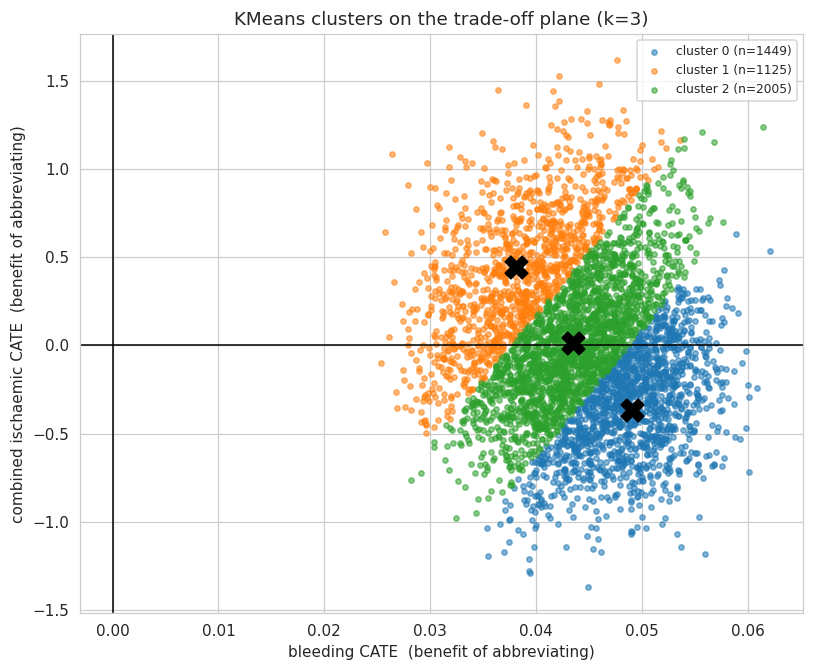

In [42]:
fig, ax = plt.subplots(figsize=(7.5, 6.2))
palette = sns.color_palette("tab10", best_k)
for cl in range(best_k):
    m = df["cluster"] == cl
    ax.scatter(df.loc[m, "bleed"], df.loc[m, "ischaemic_combined"],
               s=12, alpha=0.55, color=palette[cl], label=f"cluster {cl} (n={int(m.sum())})")
# centroid markers
cc = df.groupby("cluster")[["bleed", "ischaemic_combined"]].mean()
ax.scatter(cc["bleed"], cc["ischaemic_combined"], marker="X", s=220, c="black", zorder=5)
ax.axvline(0, color="k", lw=1); ax.axhline(0, color="k", lw=1)
ax.set_xlabel("bleeding CATE  (benefit of abbreviating)")
ax.set_ylabel("combined ischaemic CATE  (benefit of abbreviating)")
ax.set_title(f"KMeans clusters on the trade-off plane (k={best_k})")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tradeoff_clusters.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8 · The conflict subgroup

Flag the top **`CONFLICT_PCT`%** by conflict score (data-driven, independent of `k`) as the
trade-off subgroup and compare it with the rest: its mean CATEs, and its **observed** event rates
by arm. This is descriptive / in-sample — a hypothesis-generating profile, not a trial estimate.

In [43]:
thr = np.percentile(df["conflict"], 100 - CONFLICT_PCT)
df["conflict_flag"] = df["conflict"] >= thr
grp = df["conflict_flag"]
print(f"conflict subgroup: {int(grp.sum())} patients ({grp.mean()*100:.1f}%), "
      f"conflict score >= {thr:.2f}\n")

summ = pd.DataFrame({
    "conflict_subgroup": df.loc[grp, ["bleed", *ISCHAEMIC_AXES, "ischaemic_combined"]].mean(),
    "rest":              df.loc[~grp, ["bleed", *ISCHAEMIC_AXES, "ischaemic_combined"]].mean(),
})
print("mean CATE (benefit of abbreviating):")
print(summ.round(4).to_string())

print("\nobserved event rate by arm within each group (raw outcomes):")
for lab in TARGET_LABELS:
    for gname, gmask in [("conflict", grp.values), ("rest", (~grp).values)]:
        sub = gmask
        r1 = Y.loc[sub & (T == 1), lab].mean()
        r0 = Y.loc[sub & (T == 0), lab].mean()
        print(f"  {lab:9s} [{gname:8s}]  prolonged={r1:.3f}  abbreviated={r0:.3f}  diff={r1-r0:+.3f}")

conflict subgroup: 687 patients (15.0%), conflict score >= 1.51

mean CATE (benefit of abbreviating):
                    conflict_subgroup    rest
bleed                          0.0510  0.0427
death                          0.0023  0.0021
mi                            -0.0057 -0.0035
stroke                        -0.0003  0.0043
ischaemic_combined            -0.4707  0.0831

observed event rate by arm within each group (raw outcomes):
  barc_235  [conflict]  prolonged=0.150  abbreviated=0.043  diff=+0.106
  barc_235  [rest    ]  prolonged=0.082  abbreviated=0.068  diff=+0.014
  death     [conflict]  prolonged=0.018  abbreviated=0.023  diff=-0.006
  death     [rest    ]  prolonged=0.020  abbreviated=0.015  diff=+0.005
  mi        [conflict]  prolonged=0.018  abbreviated=0.043  diff=-0.026
  mi        [rest    ]  prolonged=0.022  abbreviated=0.023  diff=-0.001
  stroke    [conflict]  prolonged=0.003  abbreviated=0.012  diff=-0.009
  stroke    [rest    ]  prolonged=0.011  abbreviated=0.0

### Who are they? Covariate profile

Standardised mean difference (SMD) of each feature, conflict subgroup minus the rest; the largest
`|SMD|` features are what the model keys on to place a patient in the trade-off corner. `|SMD| > 0.2`
is a conventional "meaningful imbalance" line.

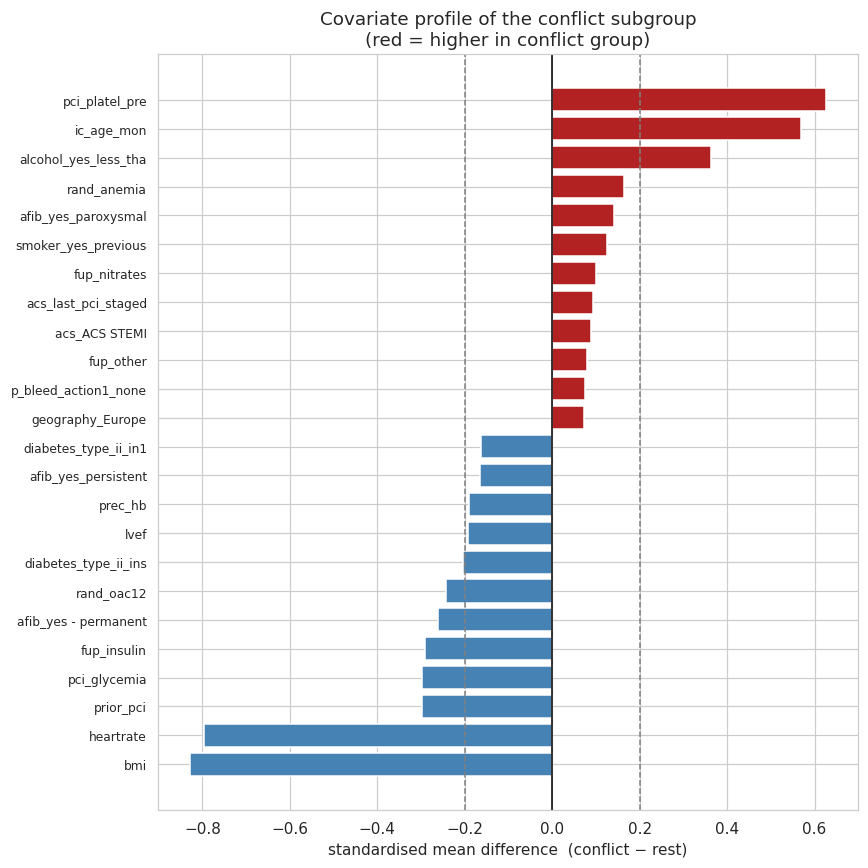

top features higher in the conflict subgroup:
pci_platel_pre          0.627
ic_age_mon              0.568
alcohol_yes_less_tha    0.364
rand_anemia             0.164
afib_yes_paroxysmal     0.141
smoker_yes_previous     0.125
fup_nitrates            0.100
acs_last_pci_staged     0.093

top features lower in the conflict subgroup:
bmi                    -0.829
heartrate              -0.796
prior_pci              -0.299
pci_glycemia           -0.298
fup_insulin            -0.291
afib_yes - permanent   -0.260
rand_oac12             -0.243
diabetes_type_ii_ins   -0.204


In [44]:
Xnum = pd.DataFrame(X_raw, columns=feat_names).apply(pd.to_numeric, errors="coerce")
g1, g0 = Xnum[grp.values], Xnum[(~grp).values]
m1, m0 = g1.mean(), g0.mean()
sd = np.sqrt((g1.var() + g0.var()) / 2).replace(0, np.nan)
smd = ((m1 - m0) / sd).dropna().sort_values()
top = pd.concat([smd.head(12), smd.tail(12)])

fig, ax = plt.subplots(figsize=(8, 8))
colors = ["firebrick" if v > 0 else "steelblue" for v in top.values]
ax.barh(range(len(top)), top.values, color=colors)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.axvline(0, color="k", lw=1)
ax.axvline(0.2, color="gray", ls="--", lw=1); ax.axvline(-0.2, color="gray", ls="--", lw=1)
ax.set_xlabel("standardised mean difference  (conflict − rest)")
ax.set_title("Covariate profile of the conflict subgroup\n(red = higher in conflict group)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tradeoff_subgroup_profile.png"), dpi=150, bbox_inches="tight")
plt.show()

print("top features higher in the conflict subgroup:")
print(smd.tail(8)[::-1].round(3).to_string())
print("\ntop features lower in the conflict subgroup:")
print(smd.head(8).round(3).to_string())

## 9 · How to read this — and how to swap the model

**Swapping model.** Change only the `path` values in the CONFIG cell (§1). Any saved
`CausalMultiOutputPipeline` works — a different flexibility preset
(`CausalForest_multioutput_flexible.joblib`), the BCF (`../models/BCF/BCF_multioutput.joblib`),
or a per-endpoint tuned forest (`dict`-wrapped, endpoint auto-detected). The loader applies each
model's own imputer/scaler, so axes may even come from different models. §6b is the one exception:
it *refits* the model, so it asserts every axis is reading `MULTIOUT`, and its cache
(`tradeoff_bootstrap.npz`) belongs to that model — **delete the cache when you swap paths.**

**Honest caveats (this cohort).**

* **The trade-off corner does not survive inference.** This is the headline. The point estimates
  put 1270 patients in the bottom-right, and §8 profiles the top 15% of them — but with the §6b
  bootstrap CIs, **0 of 4579** patients have their 95% CI wholly inside that quadrant. On both
  axes the within-patient bootstrap sd is roughly *twice* the across-patient spread of the
  estimates (signal/noise ≈ 0.57 bleeding, ≈ 0.52 ischaemic), so the plane's apparent structure is
  mostly estimation error. Read §7–§8 through this: the clusters and the conflict subgroup are
  slices of one noisy cloud, not responder groups.
* **What is real is the average, not the heterogeneity.** 99.2% of patients have a significantly
  positive bleeding benefit of abbreviating — the effect is strong and near-universal, which is
  precisely why nobody stands out against it. Consistent with nb 07 and the policy-value null in
  `10_personalized_dapt_policy.ipynb`: no rule beats treating everyone the same.
* **Magnitudes.** Re-read §4 every time you swap model — an axis is only trustworthy where the
  mean CATE agrees in sign with the raw ATE. Treat the axes as a *relative* ranking, which is why
  §7 clusters on standardised values.
* **In-sample.** The §5 CATEs and the §8 profile use full-data predictions — descriptive, not a
  cross-fitted policy estimate. §6b quantifies the sampling uncertainty of the fit; it is not an
  out-of-sample validation either.
